# Employee Attrition Prediction using Decision Trees and Random Forests

In [1]:
# BLOCK NO - 01
# 1. IMPORT & CONFIG

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot setting
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# BLOCK NO - 02
# 2. LOAD THE DATSET
df = pd.read_csv('../DATA/raw/Employee Attrition Prediction Dataset.csv')
print("✅ DATASET LOADED SUCCESSFULLY.")

✅ DATASET LOADED SUCCESSFULLY.


In [3]:
# BLOCK NO - 03
# 3. SHAPE, HEAD, INFO

print("=" * 60)
print("DATASET SHAPE")
print("=" * 60)

print("=" * 60)
print("FIRST 5 ROWS")
print("=" * 60)
print(df.head())

print("\n" + "=" * 60)
print("DATASET INFO")
print("=" * 60)
df.info()

DATASET SHAPE
FIRST 5 ROWS
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   Distance From Home  Education Education Field  Employee Count  \
0                   1          2   Life Sciences               1   
1                   8          1   Life Sciences               1   
2                   2          2           Other               1   
3                   3          4   Life Sciences               1   
4                   2          1         Medical               1   

   Employee Number  ...  Relationship Satisfaction Standard Hours  \
0                1  ...                          1

# BLOCK NO -> 04

In [4]:
# 4. TARGET VARIABLE INSPECTION

print("=" * 60)
print("TARGET VARIABLE: Attrition")
print("=" * 60)

print(df['Attrition'].value_counts())
print(f"\nAttrition Rate: {(df['Attrition'].value_counts(normalize = True)['Yes'] * 100):.2f}%")

# Numerical vs Categorial Fetures
numerical_cols = df.select_dtypes(include = ['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include = ['object']).columns.tolist()

print(f"\nNumerical Features ({len(numerical_cols)}): {numerical_cols}")
print(f"\nCategorical Features ({len(categorical_cols)}): {categorical_cols}")

TARGET VARIABLE: Attrition
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Rate: 16.12%

Numerical Features (26): ['Age', 'DailyRate', 'Distance From Home', 'Education', 'Employee Count', 'Employee Number', 'Environment Satisfaction', 'Hourly Rate', 'Job Involvement', 'Job Level', 'Job Satisfaction', 'Monthly Income', 'Monthly Rate', 'Num Companies Worked', 'Percent Salary Hike', 'Performance Rating', 'Relationship Satisfaction', 'Standard Hours', 'Stock Option Level', 'Total Working Years', 'Training Times LastYear', 'Work Life Balance', 'Years At Company', 'Years In CurrentRole', 'Years Since Last Promotion', 'Years With Curr Manager']

Categorical Features (9): ['Attrition', 'BusinessTravel', 'Department', 'Education Field', 'Gender', 'JobRole', 'Marital Status', 'Over 18', 'OverTime']


# BLOCK NO -> 05

In [5]:
print("=" * 60)
print("MISSING VALUES")
print("=" * 60)

missing = df.isnull().sum()
if missing.sum() == 0:
    print("✅ No Missing values Found!")
else:
    print(missing[missing > 0]) 

print("=" * 60)
print("CONSTANT / ID COLUMNS")
print("=" * 60)

constant_cols = [col for col in df.columns if df[col].nunique() == 1]
id_cols = [col for col in df.columns if df[col].nunique() == len(df)]
print(f"Constant Columns: {constant_cols if constant_cols else 'None'}")
print(f"ID Columns: {id_cols if id_cols else 'None'}")

MISSING VALUES
✅ No Missing values Found!
CONSTANT / ID COLUMNS
Constant Columns: ['Employee Count', 'Over 18', 'Standard Hours']
ID Columns: ['Employee Number']


# BLOCK NO -> 06

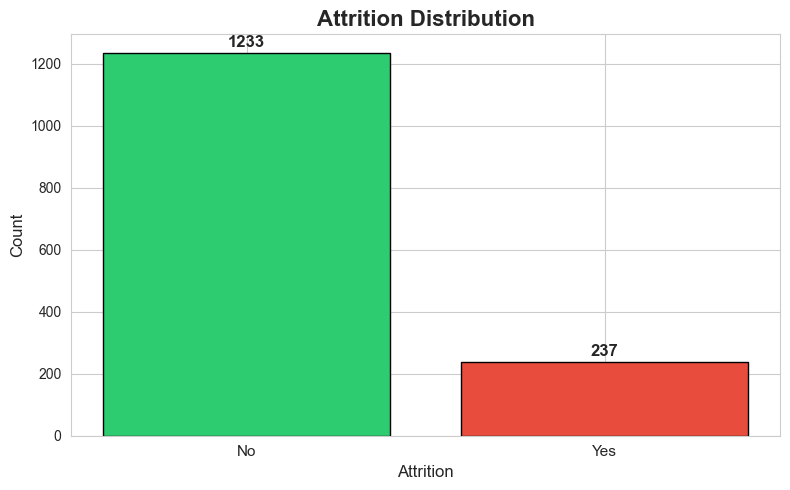

Class Imbalance Observed: 'No' attrition  dominates the dataset significantly.
This will require balancing techniques before modeling with Decision Trees or random forests.


In [6]:
# 6. GRAPH 01: ATTRITION DISTRIBUTION
plt.figure(figsize = (8, 5))
attrition_counts = df['Attrition'].value_counts()
colors = ['#2ecc71', '#e74c3c']
plt.bar(attrition_counts.index, attrition_counts.values, color = colors, edgecolor = '#000000')
plt.title("Attrition Distribution", fontsize = 16, fontweight = 'bold')
plt.xlabel("Attrition", fontsize = 12)
plt.ylabel("Count", fontsize = 12)
plt.xticks(fontsize = 11)

for i, v in enumerate(attrition_counts.values):
    plt.text(i, v + 20, str(v), ha = 'center', fontsize = 12, fontweight = 'bold')
plt.tight_layout()
plt.grid(0.2)
plt.show()

print("Class Imbalance Observed: 'No' attrition  dominates the dataset significantly.")
print("This will require balancing techniques before modeling with Decision Trees or random forests.")

# BLOCK NO -> 07

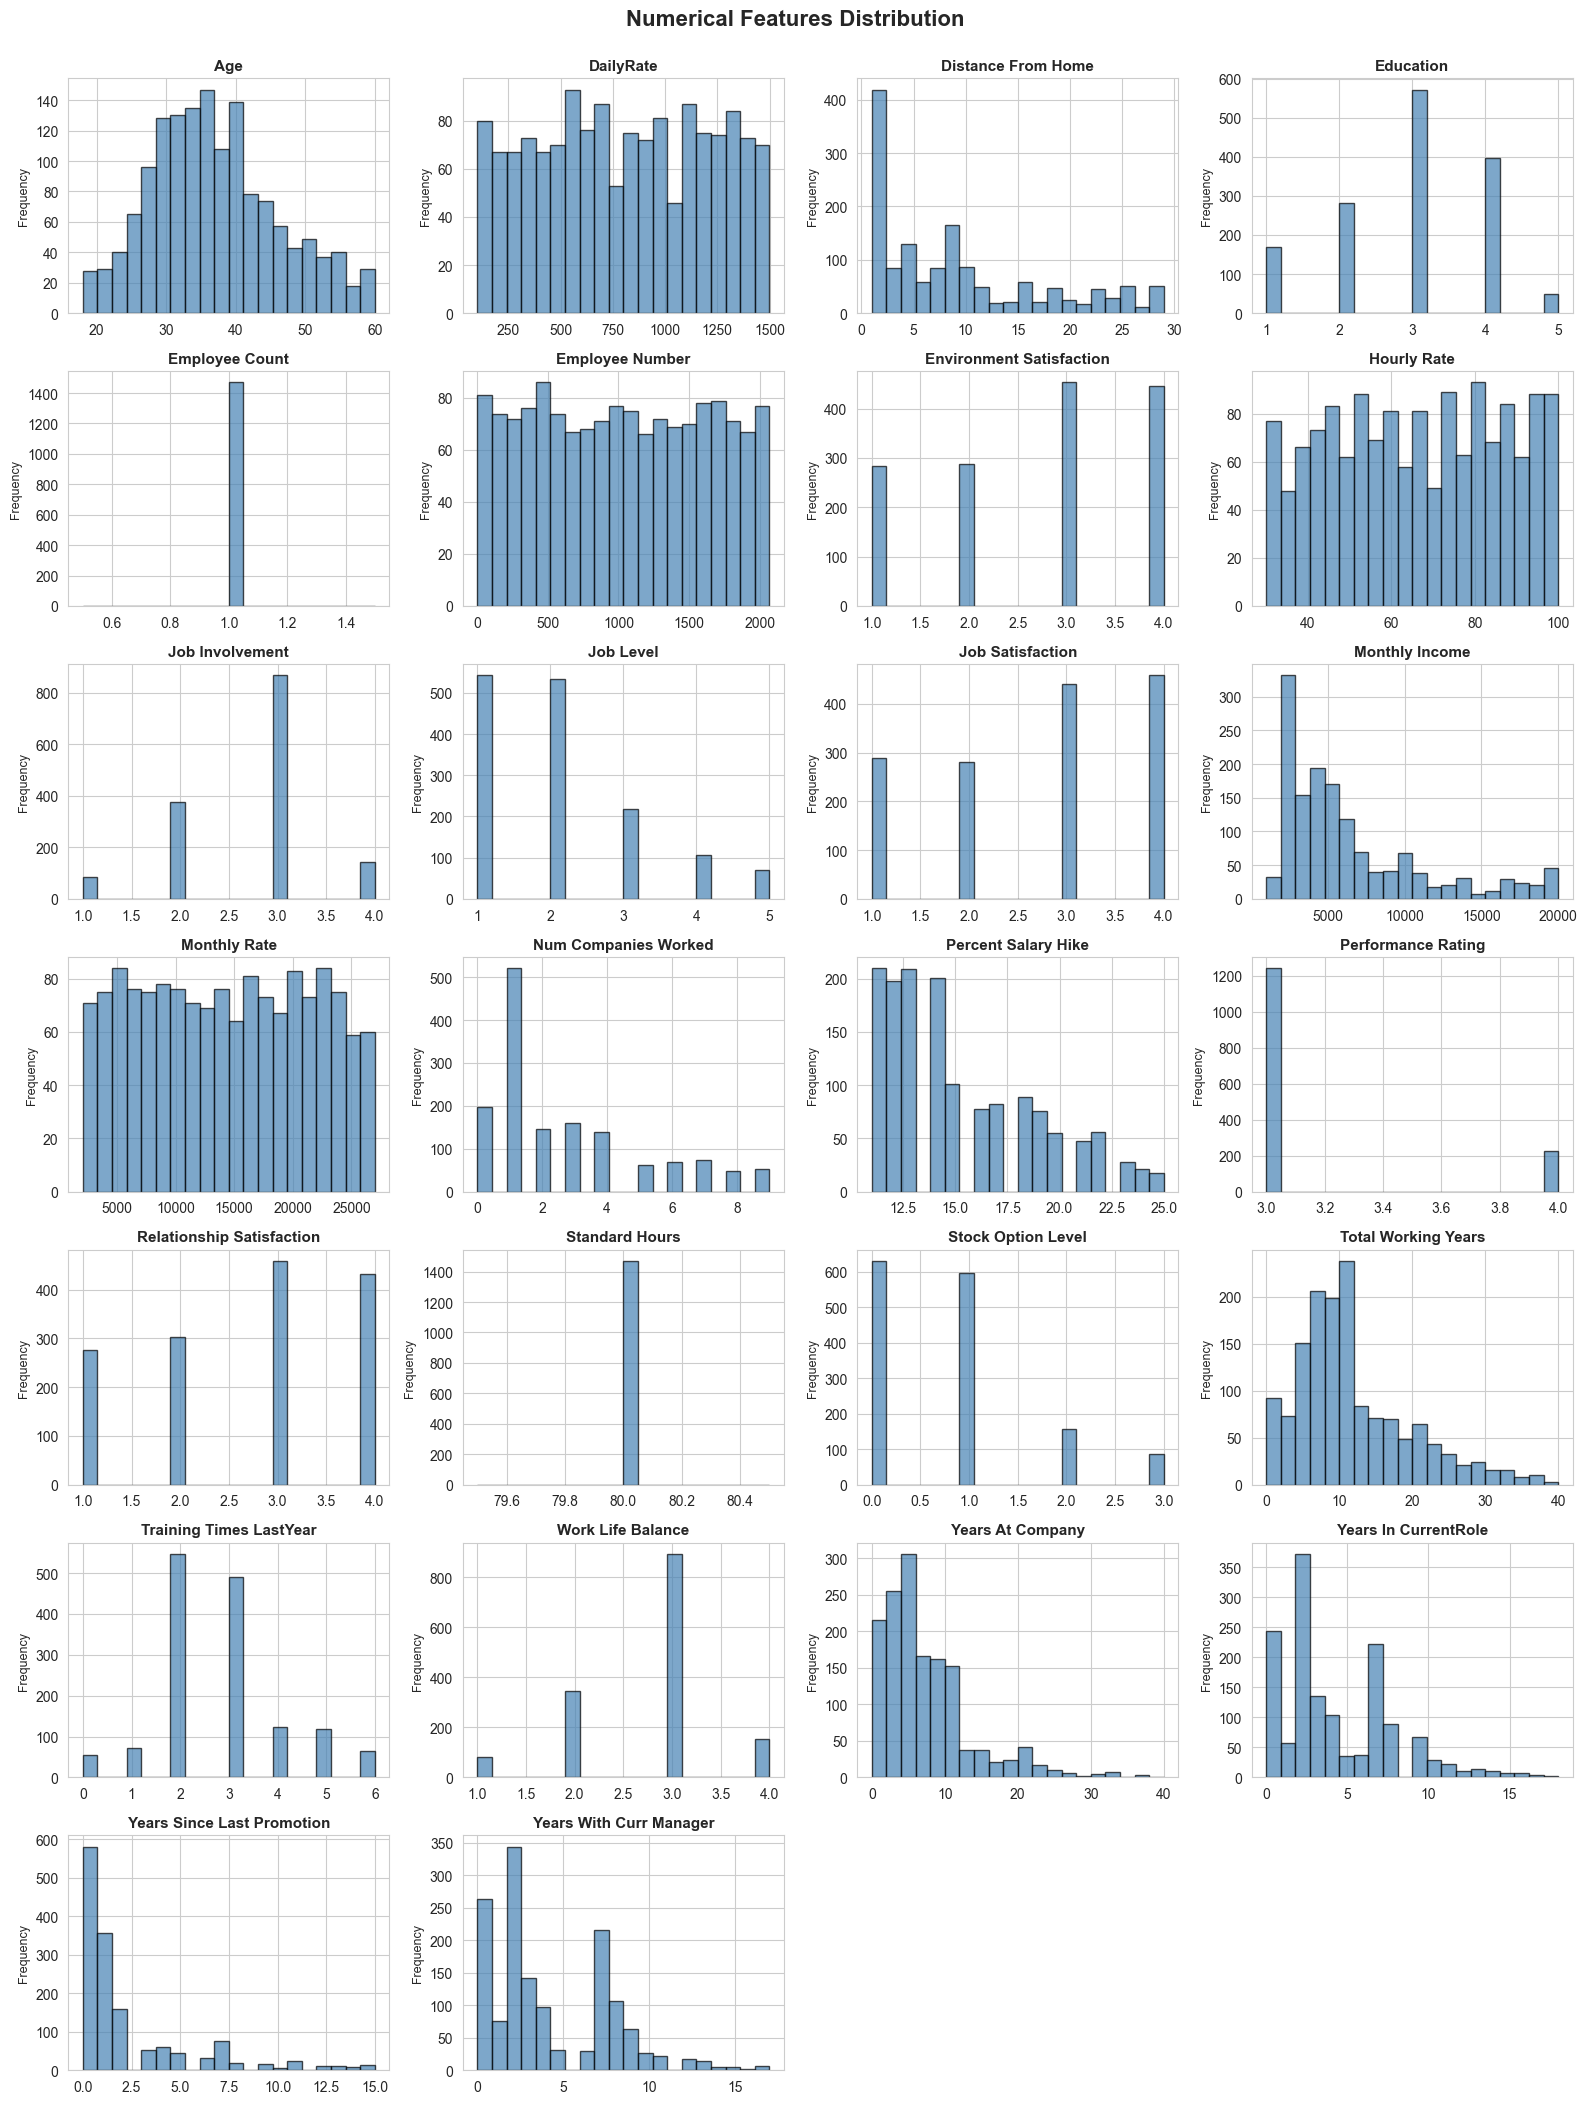

Numerical features show varied distributions; some are skewed while others are more uniform.
Feature scaling will be crucial for optimal Decision Tree and Random Forest performance.


In [7]:
# 7. GRAPH 2: NUMERICAL FEATURES OVERVIEW
numerical_features = [col for col in numerical_cols if col not in ['EmployeeNumber']]
n_features = len(numerical_features)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows*3))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    axes[i].hist(df[col], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency', fontsize=9)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Numerical Features Distribution', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("Numerical features show varied distributions; some are skewed while others are more uniform.")
print("Feature scaling will be crucial for optimal Decision Tree and Random Forest performance.")

# BLOCK NO -> 08

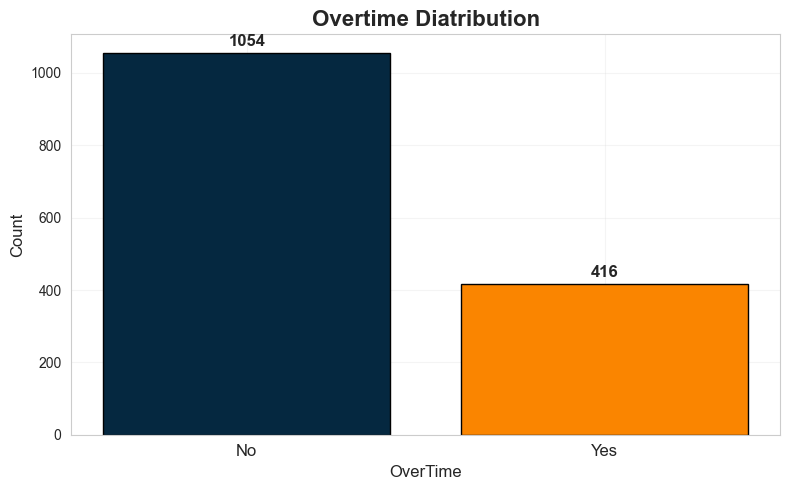

Majority of employees donot work overtime; this feature may correlated with attrition.
Decision Trees can effectively capture this categorial split during model training.


In [8]:
# 8.GRAPH 03: OVERTIME DISTRIBUTION

plt.figure(figsize = (8, 5))
OverTime_counts = df['OverTime'].value_counts()
colors = ["#052840", "#fa8500"]

plt.bar(OverTime_counts.index, OverTime_counts.values, color = colors, edgecolor = '#000000')
plt.title("Overtime Diatribution", fontsize = 16, fontweight = 'bold')
plt.xlabel('OverTime', fontsize = 12)
plt.ylabel('Count', fontsize = 12)
plt.xticks(fontsize = 12)

for i, v in enumerate(OverTime_counts.values):
    plt.text(i , v + 20, str(v), ha = 'center', fontsize = 12, fontweight = 'bold')
plt.tight_layout()
plt.grid(alpha = 0.2)
plt.show()

print("Majority of employees donot work overtime; this feature may correlated with attrition.")
print("Decision Trees can effectively capture this categorial split during model training.")

# BLOCK NO -> 09

Checking column names with 'Job' or 'Role':
['Job Involvement', 'Job Level', 'JobRole', 'Job Satisfaction', 'Years In CurrentRole']


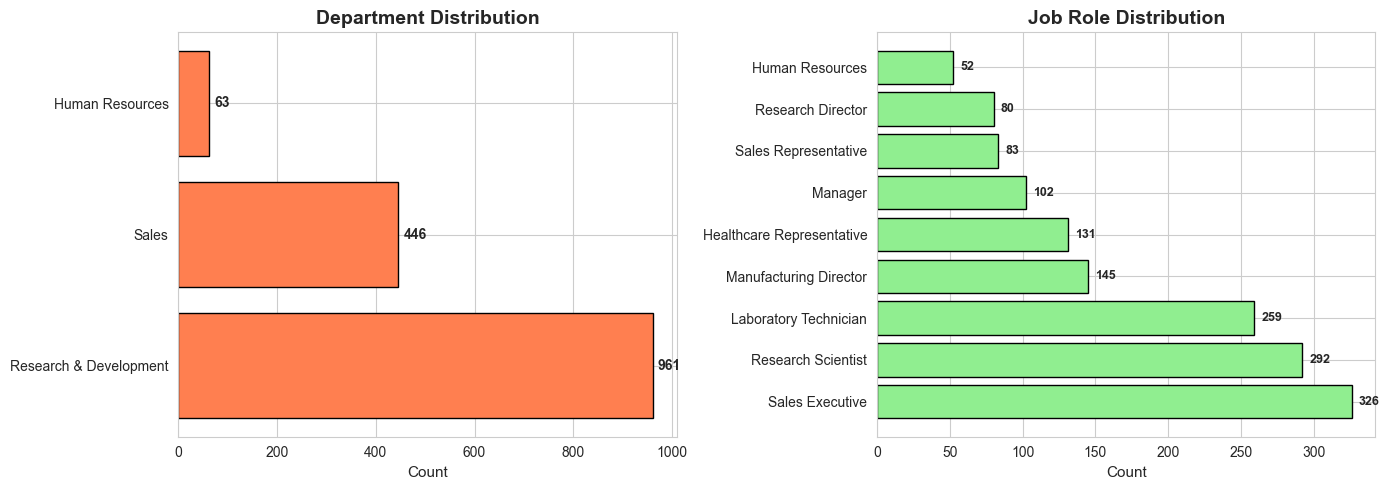

Research & Development is the largest department; Sales Executive is the most common job role.
Random Forests will handle these multi-class categorical features through feature importance ranking.


In [9]:
# 9. GRAPH 4 (OPTIONAL): DEPARTMENT & JOBROLE FREQUENCY

# First, let's check the exact column name
print("Checking column names with 'Job' or 'Role':")
job_cols = [col for col in df.columns if 'Job' in col or 'Role' in col]
print(job_cols)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Department
dept_counts = df['Department'].value_counts()
axes[0].barh(dept_counts.index, dept_counts.values, color='coral', edgecolor='black')
axes[0].set_title('Department Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Count', fontsize=11)
for i, v in enumerate(dept_counts.values):
    axes[0].text(v + 10, i, str(v), va='center', fontsize=10, fontweight='bold')

# Job Role - using the exact column name from your list
JobRole_counts = df['JobRole'].value_counts()
axes[1].barh(JobRole_counts.index, JobRole_counts.values, color='lightgreen', edgecolor='black')
axes[1].set_title('Job Role Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Count', fontsize=11)
for i, v in enumerate(JobRole_counts.values):
    axes[1].text(v + 5, i, str(v), va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("Research & Development is the largest department; Sales Executive is the most common job role.")
print("Random Forests will handle these multi-class categorical features through feature importance ranking.")

In [10]:

# filepath: 01_data_exploration.ipynb
# Add this after loading the dataset
print("All columns in the dataframe:")
print(df.columns.tolist())

All columns in the dataframe:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'Distance From Home', 'Education', 'Education Field', 'Employee Count', 'Employee Number', 'Environment Satisfaction', 'Gender', 'Hourly Rate', 'Job Involvement', 'Job Level', 'JobRole', 'Job Satisfaction', 'Marital Status', 'Monthly Income', 'Monthly Rate', 'Num Companies Worked', 'Over 18', 'OverTime', 'Percent Salary Hike', 'Performance Rating', 'Relationship Satisfaction', 'Standard Hours', 'Stock Option Level', 'Total Working Years', 'Training Times LastYear', 'Work Life Balance', 'Years At Company', 'Years In CurrentRole', 'Years Since Last Promotion', 'Years With Curr Manager']


# BLOCK NO -> 10

In [11]:
# 10. MARKDOWN SUMMARY
print("="*60)
print("📋 DATA EXPLORATION SUMMARY")
print("="*60)

print(f"\n✅ Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"✅ Target Variable: Attrition (Binary Classification)")
print(f"✅ Attrition Rate: {(df['Attrition'].value_counts(normalize=True)['Yes']*100):.2f}%")
print(f"✅ Missing Values: {'None' if df.isnull().sum().sum() == 0 else df.isnull().sum().sum()}")
print(f"✅ Constant Columns: {constant_cols if constant_cols else 'None'}")
print(f"✅ ID Columns: {id_cols if id_cols else 'None'}")
print(f"\n✅ Numerical Features: {len(numerical_cols)} columns")
print(f"✅ Categorical Features: {len(categorical_cols)} columns")

print("\n" + "="*60)
print("🔍 KEY OBSERVATIONS")
print("="*60)
print("• Significant class imbalance detected in target variable")
print("• No missing values - dataset is clean")
print("• Mix of numerical and categorical features suitable for tree-based models")
print("• OverTime and Department show clear patterns")
print("• Feature engineering and encoding required for categorical variables")

print("\n" + "="*60)
print("🎯 NEXT STEPS")
print("="*60)
print("→ Notebook 02: Data Preprocessing & Feature Engineering")
print("→ Handle class imbalance (SMOTE/undersampling)")
print("→ Encode categorical variables (One-Hot/Label Encoding)")
print("→ Feature scaling for numerical variables")
print("→ Split data into train/test sets")
print("="*60)

📋 DATA EXPLORATION SUMMARY

✅ Dataset Shape: 1470 rows × 35 columns
✅ Target Variable: Attrition (Binary Classification)
✅ Attrition Rate: 16.12%
✅ Missing Values: None
✅ Constant Columns: ['Employee Count', 'Over 18', 'Standard Hours']
✅ ID Columns: ['Employee Number']

✅ Numerical Features: 26 columns
✅ Categorical Features: 9 columns

🔍 KEY OBSERVATIONS
• Significant class imbalance detected in target variable
• No missing values - dataset is clean
• Mix of numerical and categorical features suitable for tree-based models
• OverTime and Department show clear patterns
• Feature engineering and encoding required for categorical variables

🎯 NEXT STEPS
→ Notebook 02: Data Preprocessing & Feature Engineering
→ Handle class imbalance (SMOTE/undersampling)
→ Encode categorical variables (One-Hot/Label Encoding)
→ Feature scaling for numerical variables
→ Split data into train/test sets


# “This notebook establishes dataset structure and basic distributions. No feature–target relationships are explored at this stage.”